# Influence on Outcomes

Variable of Interest and Covariates
- y_hat = percentage differences in avoided emissions
- x1 = region (cat)
- x2 = time of day (cat)
- x3 = amount of flex time (float)

Methods
- CPQE analysis
- OLS
    - log transformed y value
    -  

In [1]:
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("/Users/jen/watttime-python-client/tests/data/processed/full_results.csv")
df = df[df["region"] != 'NL']
   

In [4]:
def categorize_time(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'
    

df["hour"] = pd.to_datetime(df.usage_window_start).dt.hour
df["month"] = pd.to_datetime(df.usage_window_start).dt.month
df["time_of_day"] = df["hour"].apply(categorize_time)
df["increments_flex_time"] = round(df["flex_time"]/15,2)

df["forecast_error"] = df["forecast"] - df["actual"]
df["forecast_percent_error"] = df["forecast_error"]/df["actual"]

In [5]:
df["charge_needed"] = df["increments_flex_time"] * df["MWh_fraction"]
df["actual_per_charge"] = df["actual"]/df["charge_needed"]
df["actual_requery15_per_charge"] = df["actual_requery15"]/df["charge_needed"]
df["change_in_emissions_per_charge"] = df["change_in_emissions"]/df["charge_needed"]

<Axes: >

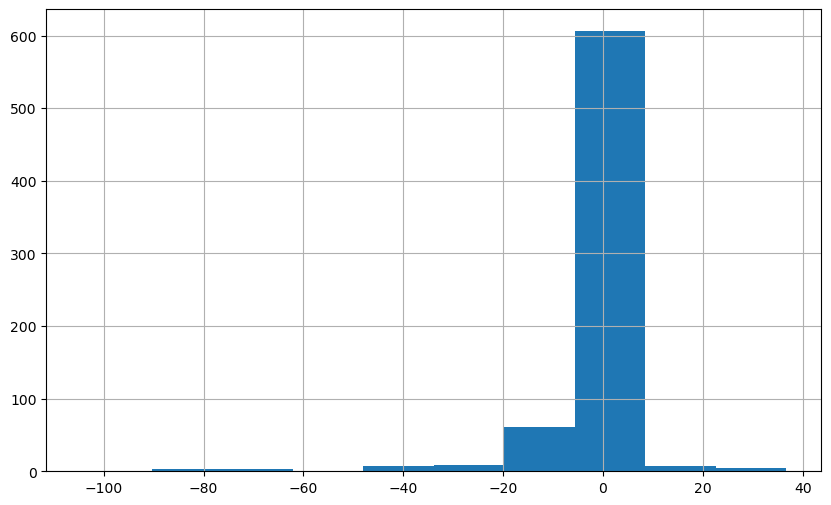

In [6]:
df.change_in_emissions.hist()

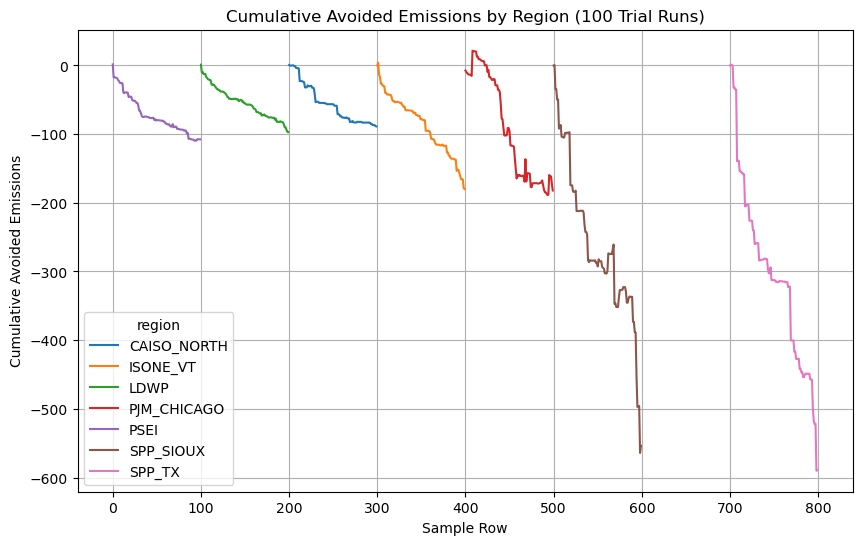

In [15]:

# Plot the cumulative sum
df.pivot(columns='region', values='change_in_emissions').cumsum().plot(kind="line")
plt.xlabel('Sample Row')
plt.ylabel('Cumulative Avoided Emissions')
plt.title('Cumulative Avoided Emissions by Region (100 Trial Runs)')
plt.grid(True)
plt.show()

In [86]:
df_lo.groupby(['region','requery'])["percent_change_emissions"].mean().apply(lambda x: round(x,2))

region       requery
CAISO_NORTH  0          -3.25
             1          -2.71
ISONE_VT     0          -6.18
             1          -6.89
LDWP         0          -2.03
             1          -2.32
PJM_CHICAGO  0           5.24
             1          -8.63
PSEI         0          -2.41
             1          -2.51
SPP_SIOUX    0          47.71
             1         -12.29
SPP_TX       0         -17.39
             1         -14.83
Name: percent_change_emissions, dtype: float64

In [88]:
df_lo.groupby(['region','requery'])["avoided_emissions"].sum().apply(lambda x: round(x,2))

region       requery
CAISO_NORTH  0          -88.80
             1          -91.77
ISONE_VT     0         -179.96
             1         -201.41
LDWP         0          -97.05
             1          -97.32
PJM_CHICAGO  0         -182.09
             1         -361.34
PSEI         0         -107.58
             1         -111.49
SPP_SIOUX    0         -553.61
             1         -636.42
SPP_TX       0         -589.30
             1         -585.70
Name: avoided_emissions, dtype: float64

<Axes: >

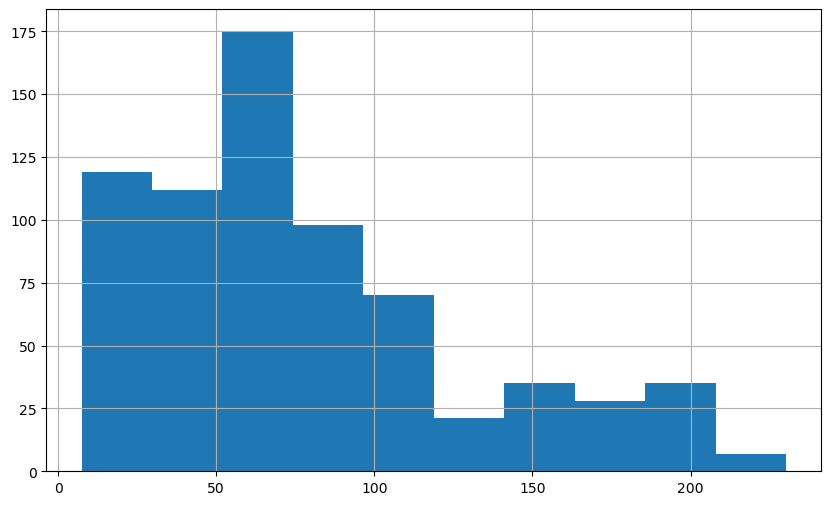

In [16]:
df["time_needed"].hist()

<Axes: >

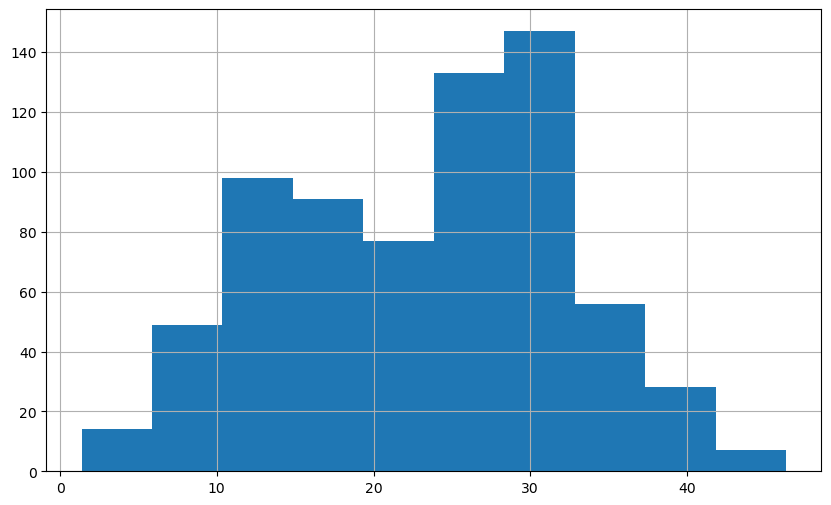

In [17]:
df["increments_flex_time"].hist()

# Log Odds

In [ ]:
import statsmodels.api as sm
import statsmodels.genmod.bayes_mixed_glm as smgb

In [70]:
def log_odds(p):
    odds = p / (1 - p)
    return np.log(odds)

In [18]:
df["requery"] = 0
df["avoided_emissions"] = df["change_in_emissions"]
df_temp = df.copy(deep=True)
df_temp["requery"] = 1
df_temp["avoided_emissions"] = df_temp["change_in_emissions_requery15"]

df_lo = pd.concat([df,df_temp],axis=0)

In [19]:
df_lo["less_than_zero"] = df_lo["avoided_emissions"] < 0
df_lo["better_than_average"] = df_lo["avoided_emissions"] < df_lo["avoided_emissions"].mean() #should be organized by region

df_lo["less_than_zero"]=df_lo["less_than_zero"].astype(int)
df_lo["better_than_average"]=df_lo["better_than_average"].astype(int)

In [20]:
df_lo["less_than_zero"].value_counts(normalize=True)

less_than_zero
1    0.65
0    0.35
Name: proportion, dtype: float64

In [111]:
model = smf.logit(
    formula='less_than_zero ~ increments_flex_time + time_needed + C(requery):C(region) + C(requery):C(time_of_day) + forecast_percent_error', 
    data=df_lo
    )
model.fit().summary()

Optimization terminated successfully.
         Current function value: 0.589580
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         less_than_zero   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1379
Method:                           MLE   Df Model:                           20
Date:                Thu, 17 Apr 2025   Pseudo R-squ.:                 0.08938
Time:                        22:17:29   Log-Likelihood:                -825.41
converged:                       True   LL-Null:                       -906.43
Covariance Type:            nonrobust   LLR p-value:                 3.047e-24
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -0.8627      0.299     -2.881      0.004      -1.450      -0.276
C(region)[T.ISONE_VT]                       0.8122      0.314      2.587      0.010       0.197       1.428
C(region)[T.LDWP]                           0.6159      0.308      2.001      0.045       0.013       1.219
C(region)[T.PJM_CHICAGO]                    0.5486      0.307      1.789      0.074      -0.052       1.150
C(region)[T.PSEI]                           0.9395      0.318      2.952      0.003       0.316       1.563
C(region)[T.SPP_SIOUX]                     -0.2572      0.302     -0.852      0.394      -0.849       0.334
C(region)[T.SPP_TX]                        -0.5009      0.310     -1.618      0.106      -1.108       0.106
C(requery)[T.1]:C(region)[CAISO_NORTH]      0.2265      0.317      0.715      0.475      -0.394       0.847
C(requery)[T.1]:C(region)[ISONE_VT]         0.2395      0.347      0.691      0.490      -0.440       0.919
C(requery)[T.1]:C(region)[LDWP]             0.2302      0.334      0.689      0.491      -0.425       0.886
C(requery)[T.1]:C(region)[PJM_CHICAGO]      0.4408      0.339      1.301      0.193      -0.223       1.105
C(requery)[T.1]:C(region)[PSEI]            -0.0880      0.343     -0.257      0.798      -0.760       0.584
C(requery)[T.1]:C(region)[SPP_SIOUX]        0.1057      0.321      0.330      0.742      -0.523       0.734
C(requery)[T.1]:C(region)[SPP_TX]           0.2491      0.329      0.758      0.448      -0.395       0.893
C(requery)[0]:C(time_of_day)[T.Evening]     1.5825      0.241      6.575      0.000       1.111       2.054
C(requery)[1]:C(time_of_day)[T.Evening]     1.1736      0.230      5.109      0.000       0.723       1.624
C(requery)[0]:C(time_of_day)[T.Morning]     0.4228      0.195      2.163      0.031       0.040       0.806
C(requery)[1]:C(time_of_day)[T.Morning]     0.3514      0.199      1.770      0.077      -0.038       0.741
increments_flex_time                        0.0142      0.006      2.184      0.029       0.001       0.027
time_needed                                 0.0041      0.001      3.345      0.001       0.002       0.006
forecast_percent_error                      0.0514      0.013      4.049      0.000       0.026       0.076
===========================================================================================================
"""

In [39]:
results = model.fit().params

Optimization terminated successfully.
         Current function value: 0.590126
         Iterations 6


In [44]:
i = results["Intercept"]
isone_vt = results["C(region)[T.ISONE_VT]"]
ldwp = results["C(region)[T.LDWP]"]
pjm_chicago = results["C(region)[T.PJM_CHICAGO]"]
psei = results["C(region)[T.PSEI]"]
spp_sioux = results["C(region)[T.SPP_SIOUX]"]
spp_tx = results["C(region)[T.SPP_TX]"]
caiso = 0
eve = results["C(time_of_day)[T.Evening]"]
morn = results["C(time_of_day)[T.Morning]"]
afternoon = 0
f = results["increments_flex_time"]
t = results["time_needed"]
e = results["forecast_percent_error"]


In [45]:
average_time_needed = df_lo.time_needed.mean()
inc_count = 2
average_e = df_lo.forecast_percent_error.mean()

In [48]:
results["C(requery)[T.1]:C(region)[CAISO_NORTH]"]

0.1319710053606425

In [ ]:
# odds of avoiding emissions compared to baseline without requery
region = caiso
time = afternoon
requery = 0

odds = np.exp(i + f*inc_count + t*average_time_needed + requery + e*average_e + region + time) 
odds / (1 + odds)

0.4064894731505658

In [54]:
# odds of avoiding emissions compared to baseline with requery
region = caiso
time = afternoon
requery = results["C(requery)[T.1]:C(region)[CAISO_NORTH]"]

odds_r = np.exp(i + f*inc_count + t*average_time_needed + requery + e*average_e + region + time) 
odds_r / (1 + odds_r)

0.43867877419480494

In [59]:
round((odds_r - odds),3)

0.097

In [108]:
region = pjm_chicago
time = eve
requery = 0

odds = np.exp(i + f*inc_count + t*average_time_needed + requery + e*average_e + region + time) 
odds / (1 + odds)

0.8230919557245162

In [107]:
region = pjm_chicago
time = eve
requery = results["C(requery)[T.1]:C(region)[CAISO_NORTH]"]

odds_r = np.exp(i + f*inc_count + t*average_time_needed + requery + e*average_e + region + time) 
odds_r / (1 + odds_r)

0.8414969907248157

In [110]:
round((odds_r - odds),3)

0.656

In [65]:
region = isone_vt
time = eve
requery = 0

odds = np.exp(i + f*inc_count + t*average_time_needed + requery + e*average_e + region + time) 
odds / (1 + odds)

0.8579621660868737

In [66]:
region = isone_vt
time = eve
requery = results["C(requery)[T.1]:C(region)[ISONE_VT]"]

odds_r = np.exp(i + f*inc_count + t*average_time_needed + requery + e*average_e + region + time) 
odds_r / (1 + odds_r)

0.8770079460854715

In [67]:
round((odds_r - odds),3)

1.09

## Maximized Results

In [73]:
df["percent_change_emissions"] = df["avoided_emissions"]/df["baseline"]*100

In [75]:
df_lo["percent_change_emissions"] = df_lo["avoided_emissions"]/df_lo["baseline"]*100

In [76]:
df_lo["less_than_five_percent"] = df_lo["percent_change_emissions"] < -5
df_lo["less_than_five_percent"]=df_lo["less_than_five_percent"].astype(int)

In [77]:
df_lo["less_than_five_percent"].value_counts(normalize=True)

less_than_five_percent
0    0.735714
1    0.264286
Name: proportion, dtype: float64

In [79]:
model = smf.logit(
    formula='less_than_five_percent ~ increments_flex_time + C(time_of_day) + C(region):C(requery) + C(region)+ forecast_percent_error',
    data=df_lo
    )
model.fit().summary()

Optimization terminated successfully.
         Current function value: 0.522855
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                             Logit Regression Results                             
==================================================================================
Dep. Variable:     less_than_five_percent   No. Observations:                 1400
Model:                              Logit   Df Residuals:                     1382
Method:                               MLE   Df Model:                           17
Date:                    Thu, 17 Apr 2025   Pseudo R-squ.:                 0.09461
Time:                            21:49:34   Log-Likelihood:                -732.00
converged:                           True   LL-Null:                       -808.49
Covariance Type:                nonrobust   LLR p-value:                 6.371e-24
==========================================================================================================
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -2.8498      0.342     -8.330      0.000      -3.520      -2.179
C(time_of_day)[T.Evening]                  0.8693      0.156      5.562      0.000       0.563       1.176
C(time_of_day)[T.Morning]                  0.5621      0.156      3.607      0.000       0.257       0.868
C(region)[T.ISONE_VT]                      0.8910      0.354      2.515      0.012       0.197       1.585
C(region)[T.LDWP]                          0.2951      0.376      0.785      0.432      -0.441       1.032
C(region)[T.PJM_CHICAGO]                   0.9230      0.353      2.613      0.009       0.231       1.615
C(region)[T.PSEI]                          0.3035      0.376      0.808      0.419      -0.433       1.040
C(region)[T.SPP_SIOUX]                     0.5432      0.365      1.489      0.136      -0.172       1.258
C(region)[T.SPP_TX]                        0.1045      0.387      0.270      0.787      -0.654       0.863
C(region)[CAISO_NORTH]:C(requery)[T.1]    -0.1614      0.402     -0.401      0.688      -0.950       0.627
C(region)[ISONE_VT]:C(requery)[T.1]        0.1431      0.309      0.463      0.643      -0.463       0.749
C(region)[LDWP]:C(requery)[T.1]            0.0635      0.357      0.178      0.859      -0.635       0.762
C(region)[PJM_CHICAGO]:C(requery)[T.1]     0.4096      0.303      1.352      0.176      -0.184       1.003
C(region)[PSEI]:C(requery)[T.1]           -0.0659      0.363     -0.181      0.856      -0.777       0.646
C(region)[SPP_SIOUX]:C(requery)[T.1]       0.2113      0.325      0.649      0.516      -0.426       0.849
C(region)[SPP_TX]:C(requery)[T.1]          0.1262      0.355      0.355      0.723      -0.570       0.823
increments_flex_time                       0.0326      0.007      4.568      0.000       0.019       0.047
forecast_percent_error                     0.0795      0.013      6.069      0.000       0.054       0.105
==========================================================================================================
"""

## Contigous

In [95]:
#df_2 = pd.read_csv("/Users/jen/watttime-python-client/tests/data/processed/contigous_full_results.csv")
df_2 = pd.read_csv("/Users/jen/watttime-python-client/tests/data/interim/con/PSEI_full.csv")

In [96]:
df_2["change_in_emissions_requery15"] = df_2["actual_requery15"] - df_2["baseline_requery15"]

In [97]:
df_2.groupby("region")[["change_in_emissions","change_in_emissions_requery15"]].sum()

,change_in_emissions,change_in_emissions_requery15
region,,
PSEI,-104.242848,-104.242848
